In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/loan_applicants.csv')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head()

Rows: 50, Columns: 15


,age,gender,marital_status,dependants,employment_status,years_employed,monthly_income_zar,monthly_expenses_zar,existing_debt_zar,num_existing_loans,loan_amount_zar,loan_purpose,loan_term_months,previous_default,defaulted
0,59,Female,Married,1,Employed,3,75215,32368,45472,1,11949,Home Finance,24,0,0
1,49,Female,Single,0,Employed,17,77042,42220,49529,0,60393,Personal,48,0,0
2,35,Female,Single,1,Self-Employed,1,23202,14998,7190,1,143013,Personal,24,0,0
3,28,Female,Single,3,Self-Employed,16,47734,22633,18640,2,30934,Personal,12,0,0
4,41,Female,Single,0,Employed,12,17435,13395,39413,1,159458,Car Finance,48,0,0


In [ ]:
print(f'Total applicants : {len(df)}')
print(f'Defaulted        : {df["defaulted"].sum()} ({df["defaulted"].mean()*100:.1f}%)')
print(f'Paid back        : {(df["defaulted"]==0).sum()} ({(df["defaulted"]==0).mean()*100:.1f}%)')
print(f'Missing values   : {df.isnull().sum().sum()}')
print()
df.describe()

== DATASET OVERVIEW ==
Total applicants : 50
Defaulted        : 12 (24.0%)
Paid back        : 38 (76.0%)
Missing values   : 0



,age,dependants,years_employed,monthly_income_zar,monthly_expenses_zar,existing_debt_zar,num_existing_loans,loan_amount_zar,loan_term_months,previous_default,defaulted
count,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,39.960000,1.220000,7.24000,33621.040000,18982.540000,19875.700000,1.100000,105311.180000,36.480000,0.240000,0.240000
std,11.217625,1.183043,6.97096,25859.331841,15896.499707,17715.997343,0.952976,53478.186813,16.255913,0.431419,0.431419
min,22.000000,0.000000,0.00000,2050.000000,1228.000000,0.000000,0.000000,10569.000000,12.000000,0.000000,0.000000
25%,31.000000,0.000000,1.00000,9705.750000,4782.250000,0.000000,0.000000,60414.500000,24.000000,0.000000,0.000000
50%,41.000000,1.000000,5.50000,26804.000000,15676.500000,19363.500000,1.000000,107832.000000,36.000000,0.000000,0.000000
75%,47.750000,2.000000,14.00000,58016.000000,29043.500000,35292.000000,2.000000,147992.500000,48.000000,0.000000,0.000000
max,59.000000,4.000000,19.00000,78588.000000,59875.000000,49529.000000,3.000000,197958.000000,60.000000,1.000000,1.000000


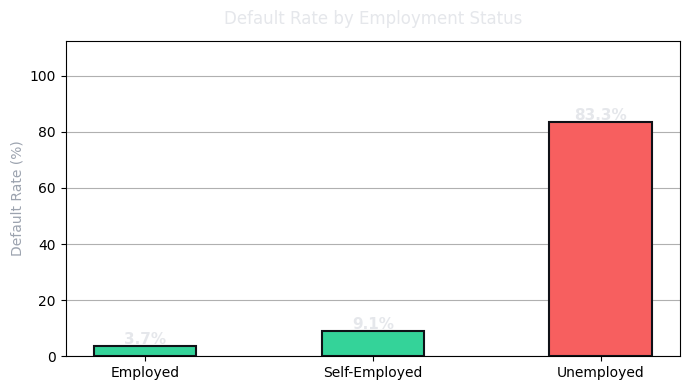

In [3]:
DANGER = '#f75f5f'; SAFE = '#34d399'; WARN = '#fbbf24'

emp_default = df.groupby('employment_status')['defaulted'].mean() * 100
colors = [DANGER if v > 30 else WARN if v > 15 else SAFE for v in emp_default.values]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(emp_default.index, emp_default.values, color=colors,
              edgecolor='#0f1117', linewidth=1.5, width=0.45)
for bar, val in zip(bars, emp_default.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', fontsize=11,
            color='#e5e7eb', fontweight='bold')
ax.set_title('Default Rate by Employment Status', color='#e5e7eb', fontsize=12, pad=12)
ax.set_ylabel('Default Rate (%)', color='#9ca3af')
ax.set_ylim(0, max(emp_default.values) * 1.35)
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

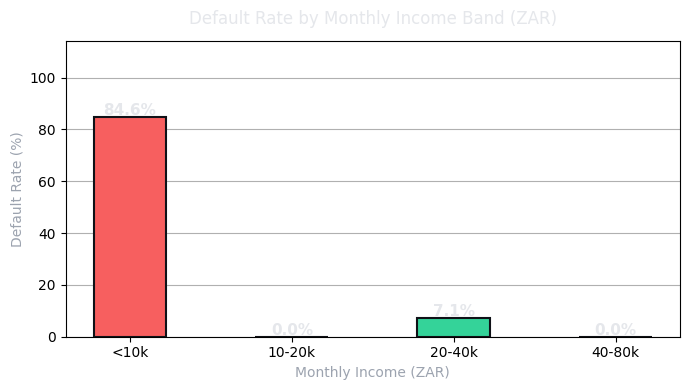

Insight: Lower income bands show higher default rates


In [4]:
bins   = [0, 10000, 20000, 40000, 80000, float('inf')]
labels = ['<10k', '10-20k', '20-40k', '40-80k', '80k+']
df['income_band'] = pd.cut(df['monthly_income_zar'], bins=bins, labels=labels)
inc_default = df.groupby('income_band', observed=True)['defaulted'].mean() * 100
colors2 = [DANGER if v > 30 else WARN if v > 15 else SAFE for v in inc_default.values]

fig, ax = plt.subplots(figsize=(7, 4))
bars2 = ax.bar(inc_default.index.astype(str), inc_default.values,
               color=colors2, edgecolor='#0f1117', linewidth=1.5, width=0.45)
for bar, val in zip(bars2, inc_default.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', fontsize=11,
            color='#e5e7eb', fontweight='bold')
ax.set_title('Default Rate by Monthly Income Band (ZAR)', color='#e5e7eb', fontsize=12, pad=12)
ax.set_ylabel('Default Rate (%)', color='#9ca3af')
ax.set_xlabel('Monthly Income (ZAR)', color='#9ca3af')
ax.set_ylim(0, max(inc_default.values) * 1.35)
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()
print('Insight: Lower income bands show higher default rates')

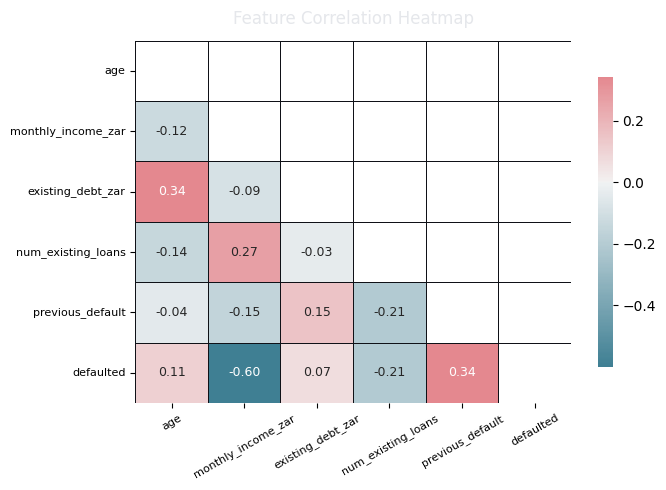

Insight: previous_default has the strongest correlation with defaulted


In [5]:
num_cols = ['age', 'monthly_income_zar', 'existing_debt_zar',
            'num_existing_loans', 'previous_default', 'defaulted']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(7, 5))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, ax=ax, cmap=cmap, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, linecolor='#0f1117',
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', color='#e5e7eb', fontsize=12, pad=12)
ax.tick_params(axis='x', labelsize=8, rotation=30)
ax.tick_params(axis='y', labelsize=8, rotation=0)
plt.tight_layout(); plt.show()
print('Insight: previous_default has the strongest correlation with defaulted')